In [1]:
"""
--->Versions<---
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas: 2.3.3
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
PySpark: 4.0.2
Gdown: 5.2.1
"""

'\n--->Versions<---\nPython: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]\nPandas: 2.3.3\nNumPy: 2.0.2\nMatplotlib: 3.10.0\nSeaborn: 0.13.2\nPySpark: 4.0.2\nGdown: 5.2.1\n'

# 1.Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType,LongType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.classification import FMClassifier, OneVsRest
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import time

# 2.Intial Setup

In [3]:
spark = (SparkSession.builder 
    .appName("HAR_BDA_Mod_2") 
    .config("spark.driver.memory", "8g") 
    .config("spark.sql.shuffle.partitions", "8") 
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 09:54:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.2


In [4]:
#Google Drive folder link
GDRIVE_URL = "https://drive.google.com/drive/folders/1TIjZJ4YOTmQ8l0-GZbQLJP8cf8R2KPKA"

DATASET_DIR = "/kaggle/working/har-dataset"
BASE_PATH = DATASET_DIR

if not os.path.exists(DATASET_DIR):
    print("Downloading dataset from Google Drive...")

    gdown.download_folder(GDRIVE_URL, quiet=False, use_cookies=False)

    print("Download complete!")


else:
    print(f"Dataset already exists at {DATASET_DIR}")

print(f"\nDataset ready at: {BASE_PATH}")

Retrieving folder contents


Processing file 1-lpsAosBf_iLkwN14BCor5y7cq88SRn_ activity_labels.txt
Processing file 1fBf678OLgErrVgohMXuQNRpRQr9aA-2d features_info.txt
Processing file 1RpWYwQtfPbXO4Yq1v2qIAP3siNBKZD15 features.txt
Processing file 1nkAGjTLxF4hGJ1PVfFZbr_NfMD_AmTXP README.txt
Processing file 13xDMhs_YQpE7K6Wxes2XP5g1bDHuycbO subject_test.txt
Processing file 1au6qgTIM4VLkoo4rtbjM8tF6YvTDJ33H subject_train.txt
Processing file 1atQLQC5ijOlzvqM6PeUTVHvmBa-2GmwD X_test.txt
Processing file 13lWHpaCP8Bs9UrjyAGOWhClw7NQMxxdL X_train.txt
Processing file 1kut01iey8L0NgZDirLfesRClXi43jmjT y_test.txt
Processing file 1-pD_UnONJe5acYCSi7O4Rdo8hzJcC2aC y_train.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-lpsAosBf_iLkwN14BCor5y7cq88SRn_
To: /kaggle/working/har-dataset/activity_labels.txt
100%|██████████| 80.0/80.0 [00:00<00:00, 282kB/s]
Downloading...
From: https://drive.google.com/uc?id=1fBf678OLgErrVgohMXuQNRpRQr9aA-2d
To: /kaggle/working/har-dataset/features_info.txt
100%|██████████| 2.81k/2.81k [00:00<00:00, 4.94MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RpWYwQtfPbXO4Yq1v2qIAP3siNBKZD15
To: /kaggle/working/har-dataset/features.txt
100%|██████████| 15.8k/15.8k [00:00<00:00, 21.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nkAGjTLxF4hGJ1PVfFZbr_NfMD_AmTXP
To: /kaggle/working/har-dataset/README.txt
100%|██████████| 6.30k/6.30k [00:00<00:00, 13.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=13xDMhs_YQpE7K6Wxes2XP5g1bDHuycbO
To: /kaggle/working/har-dataset/subject_test.txt
100%|██████████| 

Download complete!

Dataset ready at: /kaggle/working/har-dataset



Download completed


In [5]:
#here we intialize the root path from where the data is present & features.txt has cols name we also extract that and stored in variable

features = pd.read_csv(f"{BASE_PATH}/features.txt",sep=r"\s+", header=None, names=["idx", "name"])
col_names = [f"{name}_{idx}" for idx, name in zip(features["idx"], features["name"])]

In [6]:
#we extracted the data from the X_train.txt & then from y_train.txt. One row in the txt files contain one row of data.
def read_X(path, col_names):
    df = spark.read.text(path)
    df = df.select(
        F.split(F.trim(F.col("value")), r"\s+").alias("vals")
    )
    cols = [
        F.col("vals")[i].cast(DoubleType()).alias(col_names[i])
        for i in range(len(col_names))
    ]
    return df.select(cols)


def read_y(path):
    return spark.read.text(path).select(
        F.trim(F.col("value")).cast(IntegerType()).alias("label")
    )

In [7]:
# we are trying to apply the join for X_train,y_train & laten on X_test,y_test
def add_row_index(df):
    schema = df.schema
    rdd_with_index = df.rdd.zipWithIndex()
    rdd_mapped = rdd_with_index.map(lambda row: row[0] + (row[1],))
    new_schema = schema.add("row_id", LongType(), False)
    return spark.createDataFrame(rdd_mapped, new_schema)

X_train = read_X(f"{BASE_PATH}/X_train.txt", col_names)
y_train = read_y(f"{BASE_PATH}/y_train.txt")

X_train = add_row_index(X_train)
y_train = add_row_index(y_train)

train_df = X_train.join(y_train, on="row_id").drop("row_id")

print(f"Train: {train_df.count()} rows × {len(train_df.columns)} cols")

26/04/17 09:55:06 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/17 09:55:06 WARN DAGScheduler: Broadcasting large task binary with size 1142.6 KiB


Train: 7352 rows × 562 cols


In [8]:
X_test = read_X(f"{BASE_PATH}/X_test.txt", col_names)
y_test = read_y(f"{BASE_PATH}/y_test.txt")

X_test = add_row_index(X_test)
y_test = add_row_index(y_test)

test_df = X_test.join(y_test, on="row_id").drop("row_id")

print(f"Test : {test_df.count()} rows × {len(test_df.columns)} cols")

26/04/17 09:55:16 WARN DAGScheduler: Broadcasting large task binary with size 1142.2 KiB


Test : 2947 rows × 562 cols


In [9]:
#you can see the first 4 columns with label column & also how many rows each label contains
train_df.select(col_names[:4] + ["label"]).show(5)

train_df.groupBy("label").count().orderBy("label").show()

26/04/17 09:55:19 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


+-------------------+-------------------+-------------------+------------------+-----+
|tBodyAcc-mean()-X_1|tBodyAcc-mean()-Y_2|tBodyAcc-mean()-Z_3|tBodyAcc-std()-X_4|label|
+-------------------+-------------------+-------------------+------------------+-----+
|         0.27965306|       -0.019467156|        -0.11346169|       -0.99537956|    5|
|           0.278457|       -0.020414761|        -0.11273172|       -0.99913488|    5|
|         0.27573444|        -0.01801884|        -0.10677578|       -0.99925496|    5|
|         0.28725164|       -0.037455064|        -0.14597431|       -0.98291504|    4|
|          0.2799976|       -0.019484036|        -0.10572355|       -0.99281839|    4|
+-------------------+-------------------+-------------------+------------------+-----+
only showing top 5 rows


26/04/17 09:55:23 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
26/04/17 09:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1214.5 KiB


+-----+-----+
|label|count|
+-----+-----+
|    1| 1226|
|    2| 1073|
|    3|  986|
|    4| 1286|
|    5| 1374|
|    6| 1407|
+-----+-----+



26/04/17 09:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1217.0 KiB


# 3.Data Analysis

In [10]:
print("Statistics of first 3 features")
stats = train_df.select(col_names[:3] + ["label"]).describe()
stats.show(truncate=True)

Statistics of first 3 features


26/04/17 09:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


+-------+-------------------+--------------------+--------------------+------------------+
|summary|tBodyAcc-mean()-X_1| tBodyAcc-mean()-Y_2| tBodyAcc-mean()-Z_3|             label|
+-------+-------------------+--------------------+--------------------+------------------+
|  count|               7352|                7352|                7352|              7352|
|   mean|0.27448812496351943|-0.01769542735779...|-0.10914102015124014|3.6433623503808485|
| stddev|0.07026133266614955|0.040810524573263486| 0.05663518808472922|1.7448018716489941|
|    min|               -1.0|                -1.0|                -1.0|                 1|
|    max|                1.0|                 1.0|                 1.0|                 6|
+-------+-------------------+--------------------+--------------------+------------------+



In [11]:
print("Mean of first 3 features grouped by activity")
per_class = train_df.select(col_names[:3]+ ["label"]).groupBy("label").mean().orderBy("label")
per_class.show(truncate=True)

Mean of first 3 features grouped by activity


26/04/17 09:55:31 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
26/04/17 09:55:34 WARN DAGScheduler: Broadcasting large task binary with size 1231.7 KiB
26/04/17 09:55:35 WARN DAGScheduler: Broadcasting large task binary with size 1238.8 KiB


+-----+------------------------+------------------------+------------------------+----------+
|label|avg(tBodyAcc-mean()-X_1)|avg(tBodyAcc-mean()-Y_2)|avg(tBodyAcc-mean()-Z_3)|avg(label)|
+-----+------------------------+------------------------+------------------------+----------+
|    1|     0.27626020087275743|    -0.01776771085111821|    -0.10888408950546494|       1.0|
|    2|     0.26192952725200414|    -0.02664705257359736|    -0.12042356442003724|       2.0|
|    3|     0.28816888847565963|    -0.01637018642175557|    -0.10586032515210761|       3.0|
|    4|      0.2734489988254274|    -0.01214260884597...|    -0.10658074499331255|       4.0|
|    5|      0.2792937570742357|    -0.01612308466366...|    -0.10732962785709045|       5.0|
|    6|     0.26919100708876986|    -0.01834524797718552|    -0.10716870963646057|       6.0|
+-----+------------------------+------------------------+------------------------+----------+



26/04/17 09:55:35 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB
26/04/17 09:55:38 WARN DAGScheduler: Broadcasting large task binary with size 1214.5 KiB
26/04/17 09:55:38 WARN DAGScheduler: Broadcasting large task binary with size 1217.1 KiB
26/04/17 09:55:38 WARN DAGScheduler: Broadcasting large task binary with size 1217.4 KiB
26/04/17 09:55:38 WARN DAGScheduler: Broadcasting large task binary with size 1216.9 KiB


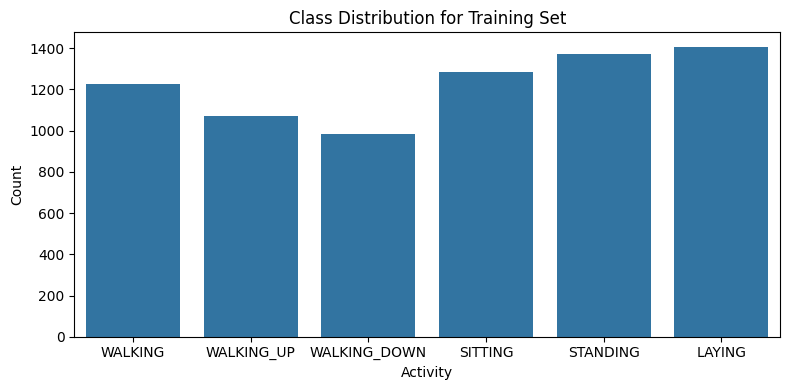

In [12]:
label_dist = train_df.groupBy("label").count().orderBy("label").toPandas()

activity_map = {
    1: "WALKING", 2: "WALKING_UP", 3: "WALKING_DOWN", 4: "SITTING", 5: "STANDING",  6: "LAYING"
}

label_dist["activity"] = label_dist["label"].map(activity_map)

plt.figure(figsize=(8, 4))
sns.barplot(data=label_dist, x="activity", y="count")
plt.title("Class Distribution for Training Set")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

26/04/17 09:55:39 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


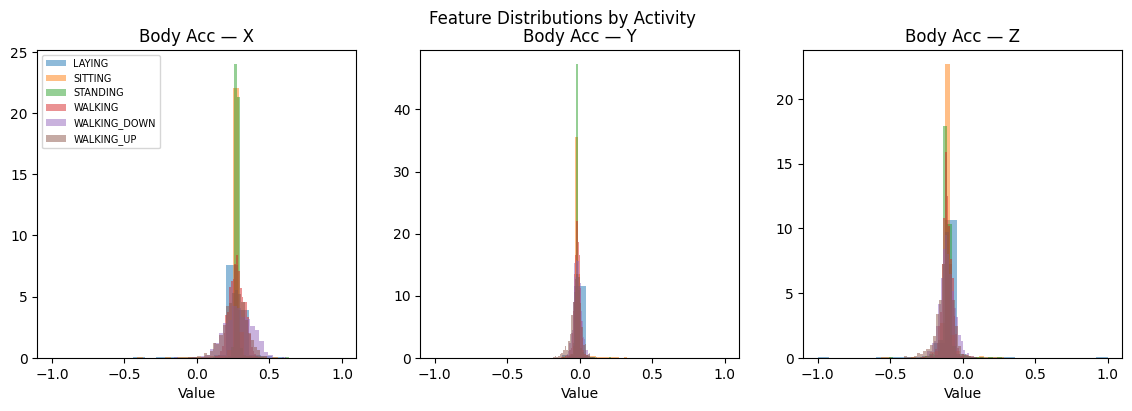

In [13]:
plot_df = train_df.select(col_names[0], col_names[1], col_names[2], "label").toPandas()
plot_df["activity"] = plot_df["label"].map(activity_map)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_to_plot = [col_names[0], col_names[1], col_names[2]]
titles = ["Body Acc — X", "Body Acc — Y", "Body Acc — Z"]

for ax, feat, title in zip(axes, features_to_plot, titles):
    for activity, group in plot_df.groupby("activity"):
        ax.hist(group[feat], bins=25, alpha=0.5, label=activity, density=True)
    ax.set_title(title)
    ax.set_xlabel("Value")

axes[0].legend(fontsize=7)
plt.suptitle("Feature Distributions by Activity", fontsize=12)
plt.show()

26/04/17 09:55:43 WARN DAGScheduler: Broadcasting large task binary with size 1142.8 KiB


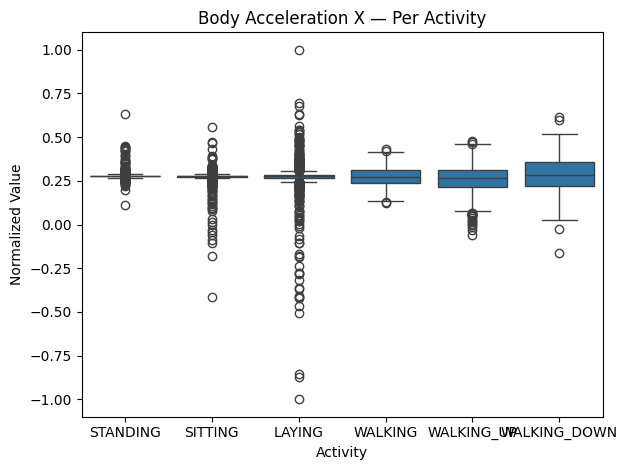

In [14]:
box_df = train_df.select(col_names[0], "label").toPandas()
box_df["activity"] = box_df["label"].map(activity_map)

sns.boxplot(data=box_df, x="activity", y=col_names[0])
plt.title("Body Acceleration X — Per Activity")
plt.xlabel("Activity")
plt.ylabel("Normalized Value")
plt.tight_layout()
plt.show()

# 4.Pre-processing

In [15]:
#We are transforming all features into one column because MLlib requires this

assembler = VectorAssembler(
    inputCols=col_names,
    outputCol="raw_features"
)

train_assembled = assembler.transform(train_df)
test_assembled  = assembler.transform(test_df)

train_assembled.select("raw_features", "label").show(3,truncate=60)

26/04/17 09:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:55:50 WARN DAGScheduler: Broadcasting large task binary with size 1387.7 KiB


+------------------------------------------------------------+-----+
|                                                raw_features|label|
+------------------------------------------------------------+-----+
|[0.27965306,-0.019467156,-0.11346169,-0.99537956,-0.96718...|    5|
|[0.278457,-0.020414761,-0.11273172,-0.99913488,-0.9846800...|    5|
|[0.27573444,-0.01801884,-0.10677578,-0.99925496,-0.993668...|    5|
+------------------------------------------------------------+-----+
only showing top 3 rows


In [16]:
#Standardscalar is used  to make the feature values mean=0 & standard_deviation=1
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)


scaler_model = scaler.fit(train_assembled)

train_scaled = scaler_model.transform(train_assembled)
test_scaled  = scaler_model.transform(test_assembled)

train_final = train_scaled.select("features", "label")
test_final  = test_scaled.select("features", "label")

print("Train:", train_final.count(), "rows")
print("Test :", test_final.count(), "rows")
train_final.show(3, truncate=60)

26/04/17 09:55:51 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:55:54 WARN DAGScheduler: Broadcasting large task binary with size 1389.8 KiB
26/04/17 09:55:56 WARN DAGScheduler: Broadcasting large task binary with size 1429.3 KiB
26/04/17 09:55:56 WARN DAGScheduler: Broadcasting large task binary with size 1161.2 KiB


Train: 7352 rows


26/04/17 09:55:59 WARN DAGScheduler: Broadcasting large task binary with size 1160.8 KiB


Test : 2947 rows


26/04/17 09:56:01 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB


+------------------------------------------------------------+-----+
|                                                    features|label|
+------------------------------------------------------------+-----+
|[0.07351034830240663,-0.043413522877544346,-0.07628949412...|    5|
|[0.056487329315802116,-0.06663314599948807,-0.06340051071...|    5|
|[0.01773827778647269,-0.007924736219093854,0.041762731461...|    5|
+------------------------------------------------------------+-----+
only showing top 3 rows


26/04/17 09:56:04 WARN DAGScheduler: Broadcasting large task binary with size 1401.7 KiB


In [17]:
#Data is being cached and because it will be used for 3 times once per ML algorithm
train_final.cache()
test_final.cache()
print(train_final.count())
print(test_final.count())

26/04/17 09:56:04 WARN DAGScheduler: Broadcasting large task binary with size 1161.0 KiB
26/04/17 09:56:06 WARN DAGScheduler: Broadcasting large task binary with size 1407.2 KiB
26/04/17 09:56:08 WARN DAGScheduler: Broadcasting large task binary with size 1413.8 KiB


7352


26/04/17 09:56:08 WARN DAGScheduler: Broadcasting large task binary with size 1160.5 KiB
26/04/17 09:56:09 WARN DAGScheduler: Broadcasting large task binary with size 1406.8 KiB


2947


26/04/17 09:56:10 WARN DAGScheduler: Broadcasting large task binary with size 1413.3 KiB


In [18]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# 6. ML Algorithms (Project Work)

# 6.1 Decision Tree

In [19]:
start = time.time()
dt = DecisionTreeClassifier(
    featuresCol="features", labelCol="label",
    maxDepth=10, seed=42
)
dt_model = dt.fit(train_final)
dt_time = time.time() - start

dt_preds = dt_model.transform(test_final)
dt_acc = evaluator_acc.evaluate(dt_preds)
dt_f1  = evaluator_f1.evaluate(dt_preds)

print(f"Decision Tree — Accuracy: {dt_acc:.4f} | F1: {dt_f1:.4f} | Time: {dt_time:.1f}s")

26/04/17 09:56:10 WARN DAGScheduler: Broadcasting large task binary with size 1422.0 KiB
26/04/17 09:56:11 WARN DAGScheduler: Broadcasting large task binary with size 1434.4 KiB
26/04/17 09:56:11 WARN DAGScheduler: Broadcasting large task binary with size 1434.2 KiB
26/04/17 09:56:11 WARN DAGScheduler: Broadcasting large task binary with size 1442.4 KiB
26/04/17 09:56:15 WARN DAGScheduler: Broadcasting large task binary with size 1582.7 KiB
26/04/17 09:56:16 WARN DAGScheduler: Broadcasting large task binary with size 1583.6 KiB
26/04/17 09:56:16 WARN DAGScheduler: Broadcasting large task binary with size 1583.9 KiB
26/04/17 09:56:16 WARN DAGScheduler: Broadcasting large task binary with size 1585.1 KiB
26/04/17 09:56:17 WARN DAGScheduler: Broadcasting large task binary with size 1586.3 KiB
26/04/17 09:56:17 WARN DAGScheduler: Broadcasting large task binary with size 1589.3 KiB
26/04/17 09:56:17 WARN DAGScheduler: Broadcasting large task binary with size 1594.4 KiB
26/04/17 09:56:18 WAR

Decision Tree — Accuracy: 0.8524 | F1: 0.8507 | Time: 9.2s


26/04/17 09:56:20 WARN DAGScheduler: Broadcasting large task binary with size 1474.4 KiB


In [20]:
dt_grid = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10, 15]).addGrid(dt.minInstancesPerNode, [1, 5]).build()

dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_grid,
    evaluator=evaluator_acc,
    numFolds=3, seed=42
)

start = time.time()
dt_cv_model = dt_cv.fit(train_final)
dt_cv_time = time.time() - start

dt_cv_preds = dt_cv_model.transform(test_final)
dt_cv_acc = evaluator_acc.evaluate(dt_cv_preds)
dt_cv_f1  = evaluator_f1.evaluate(dt_cv_preds)

print(f"DT tuned — Accuracy: {dt_cv_acc:.4f} | F1: {dt_cv_f1:.4f} | Time: {dt_cv_time:.1f}s")
print(f"Best maxDepth          : {dt_cv_model.bestModel.getMaxDepth()}")
print(f"Best minInstancesPerNode: {dt_cv_model.bestModel.getMinInstancesPerNode()}")

26/04/17 09:56:20 WARN DAGScheduler: Broadcasting large task binary with size 1420.8 KiB
26/04/17 09:56:20 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1446.2 KiB
26/04/17 09:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1446.0 KiB
26/04/17 09:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1454.2 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1594.5 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1595.3 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1596.1 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1597.2 KiB
26/04/17 09:56:23 WARN DAGScheduler: Broadcasting large task binary with size 1599.1 KiB
26/04/17 09:56:24 WARN DAGScheduler: Broadcasting large task binary with size 1420.7 KiB
26/04/17 09:56:24 WAR

DT tuned — Accuracy: 0.8616 | F1: 0.8597 | Time: 86.5s
Best maxDepth          : 10
Best minInstancesPerNode: 5


# 6.2 Factorization Machines

In [21]:

start = time.time()
fm = FMClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    stepSize=0.001,
    seed=42
)
fm_ovr = OneVsRest(classifier=fm, featuresCol="features", labelCol="label")
fm_model = fm_ovr.fit(train_final)
fm_time = time.time() - start

fm_preds = fm_model.transform(test_final)
fm_acc = evaluator_acc.evaluate(fm_preds)
fm_f1  = evaluator_f1.evaluate(fm_preds)

print(f"FM (OvR) — Accuracy: {fm_acc:.4f} | F1: {fm_f1:.4f} | Time: {fm_time:.1f}s")

26/04/17 09:57:47 WARN DAGScheduler: Broadcasting large task binary with size 1414.1 KiB
26/04/17 09:57:48 WARN DAGScheduler: Broadcasting large task binary with size 1430.8 KiB
26/04/17 09:57:49 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:57:50 WARN DAGScheduler: Broadcasting large task binary with size 1434.9 KiB
26/04/17 09:57:50 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:57:51 WARN DAGScheduler: Broadcasting large task binary with size 1434.9 KiB
26/04/17 09:57:51 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:57:52 WARN DAGScheduler: Broadcasting large task binary with size 1434.9 KiB
26/04/17 09:57:52 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:57:53 WARN DAGScheduler: Broadcasting large task binary with size 1434.9 KiB
26/04/17 09:57:53 WARN DAGScheduler: Broadcasting large task binary with size 1433.9 KiB
26/04/17 09:57:54 WAR

FM (OvR) — Accuracy: 0.9270 | F1: 0.9268 | Time: 693.7s


In [22]:
fm_grid = ParamGridBuilder().addGrid(fm.stepSize, [0.001, 0.01]).build()

fm_cv = CrossValidator(
    estimator=fm_ovr,
    estimatorParamMaps=fm_grid,
    evaluator=evaluator_acc,
    numFolds=3, seed=42
)

start = time.time()
fm_cv_model = fm_cv.fit(train_final)
fm_cv_time  = time.time() - start

fm_cv_preds = fm_cv_model.transform(test_final)
fm_cv_acc   = evaluator_acc.evaluate(fm_cv_preds)
fm_cv_f1    = evaluator_f1.evaluate(fm_cv_preds)

print(f"FM tuned — Accuracy: {fm_cv_acc:.4f} | F1: {fm_cv_f1:.4f} | Time: {fm_cv_time:.1f}s")

26/04/17 10:09:37 WARN DAGScheduler: Broadcasting large task binary with size 1420.8 KiB
26/04/17 10:09:37 WARN DAGScheduler: Broadcasting large task binary with size 1425.9 KiB
26/04/17 10:09:37 WARN DAGScheduler: Broadcasting large task binary with size 1442.6 KiB
26/04/17 10:09:37 WARN DAGScheduler: Broadcasting large task binary with size 1445.8 KiB
26/04/17 10:09:38 WARN DAGScheduler: Broadcasting large task binary with size 1446.8 KiB
26/04/17 10:09:38 WARN DAGScheduler: Broadcasting large task binary with size 1445.8 KiB
26/04/17 10:09:39 WARN DAGScheduler: Broadcasting large task binary with size 1446.8 KiB
26/04/17 10:09:39 WARN DAGScheduler: Broadcasting large task binary with size 1445.8 KiB
26/04/17 10:09:39 WARN DAGScheduler: Broadcasting large task binary with size 1446.8 KiB
26/04/17 10:09:39 WARN DAGScheduler: Broadcasting large task binary with size 1445.8 KiB
26/04/17 10:09:40 WARN DAGScheduler: Broadcasting large task binary with size 1446.8 KiB
26/04/17 10:09:40 WAR

FM tuned — Accuracy: 0.9315 | F1: 0.9314 | Time: 3695.1s


# 6.3 Multi-Later Perceptron

In [23]:
from pyspark.ml.classification import MultilayerPerceptronClassifier


train_mlp = train_final.withColumn("label", F.col("label") - 1)
test_mlp  = test_final.withColumn("label",  F.col("label") - 1)

layers = [561, 128, 64, 6]   # 561 inputs → 128 → 64 → 6 outputs

start = time.time()
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=layers,
    maxIter=100,
    seed=42,
    blockSize=128,
    stepSize=0.03,
    solver="l-bfgs"
)
mlp_model = mlp.fit(train_mlp)
mlp_time = time.time() - start

mlp_preds = mlp_model.transform(test_mlp)
mlp_acc = evaluator_acc.evaluate(mlp_preds)
mlp_f1  = evaluator_f1.evaluate(mlp_preds)

print(f"MLP — Accuracy: {mlp_acc:.4f} | F1: {mlp_f1:.4f} | Time: {mlp_time:.1f}s")


26/04/17 11:11:26 WARN DAGScheduler: Broadcasting large task binary with size 1449.8 KiB
26/04/17 11:11:26 WARN DAGScheduler: Broadcasting large task binary with size 1452.9 KiB
26/04/17 11:11:28 WARN DAGScheduler: Broadcasting large task binary with size 1453.9 KiB
26/04/17 11:11:28 WARN DAGScheduler: Broadcasting large task binary with size 1452.9 KiB
26/04/17 11:11:31 WARN DAGScheduler: Broadcasting large task binary with size 1453.9 KiB
26/04/17 11:11:31 WARN DAGScheduler: Broadcasting large task binary with size 1452.9 KiB
26/04/17 11:11:34 WARN DAGScheduler: Broadcasting large task binary with size 1453.9 KiB
26/04/17 11:11:34 WARN DAGScheduler: Broadcasting large task binary with size 1452.9 KiB
26/04/17 11:11:36 WARN DAGScheduler: Broadcasting large task binary with size 1453.9 KiB
26/04/17 11:11:36 WARN DAGScheduler: Broadcasting large task binary with size 1452.9 KiB
26/04/17 11:11:39 WARN DAGScheduler: Broadcasting large task binary with size 1453.9 KiB
26/04/17 11:11:39 WAR

MLP — Accuracy: 0.9332 | F1: 0.9333 | Time: 276.8s


26/04/17 11:16:03 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


In [24]:
mlp_grid = ParamGridBuilder().addGrid(mlp.stepSize, [0.03, 0.05]).build()

mlp_cv = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=mlp_grid,
    evaluator=evaluator_acc,
    numFolds=3,
    seed=42
)

start = time.time()
mlp_cv_model = mlp_cv.fit(train_mlp)        
mlp_cv_time  = time.time() - start

mlp_cv_preds = mlp_cv_model.transform(test_mlp)  
mlp_cv_acc   = evaluator_acc.evaluate(mlp_cv_preds)
mlp_cv_f1    = evaluator_f1.evaluate(mlp_cv_preds)

print(f"MLP tuned — Accuracy: {mlp_cv_acc:.4f} | F1: {mlp_cv_f1:.4f} | Time: {mlp_cv_time:.1f}s")
print(f"Best stepSize: {mlp_cv_model.bestModel.getStepSize()}")

26/04/17 11:16:03 WARN DAGScheduler: Broadcasting large task binary with size 1421.3 KiB
26/04/17 11:16:03 WARN DAGScheduler: Broadcasting large task binary with size 1461.3 KiB
26/04/17 11:16:04 WARN DAGScheduler: Broadcasting large task binary with size 1464.4 KiB
26/04/17 11:16:07 WARN DAGScheduler: Broadcasting large task binary with size 1465.4 KiB
26/04/17 11:16:07 WARN DAGScheduler: Broadcasting large task binary with size 1464.4 KiB
26/04/17 11:16:09 WARN DAGScheduler: Broadcasting large task binary with size 1465.4 KiB
26/04/17 11:16:09 WARN DAGScheduler: Broadcasting large task binary with size 1464.4 KiB
26/04/17 11:16:10 WARN DAGScheduler: Broadcasting large task binary with size 1465.4 KiB
26/04/17 11:16:10 WARN DAGScheduler: Broadcasting large task binary with size 1464.4 KiB
26/04/17 11:16:12 WARN DAGScheduler: Broadcasting large task binary with size 1465.4 KiB
26/04/17 11:16:12 WARN DAGScheduler: Broadcasting large task binary with size 1464.4 KiB
26/04/17 11:16:14 WAR

MLP tuned — Accuracy: 0.9332 | F1: 0.9333 | Time: 1429.2s
Best stepSize: 0.03


In [25]:
results = pd.DataFrame({
    "Algorithm":  ["Decision Tree", "Decision Tree (tuned)",
                   "Factorization Machine", "Factorization Machine (tuned)",
                   "MLP", "MLP (tuned)"],
    "Accuracy":   [dt_acc, dt_cv_acc, fm_acc, fm_cv_acc, mlp_acc, mlp_cv_acc],
    "F1 Score":   [dt_f1,  dt_cv_f1,  fm_f1,  fm_cv_f1,  mlp_f1,  mlp_cv_f1],
    "Time (s)":   [dt_time, dt_cv_time, fm_time, fm_cv_time, mlp_time, mlp_cv_time]
})

results["Accuracy"] = results["Accuracy"].map("{:.4f}".format)
results["F1 Score"] = results["F1 Score"].map("{:.4f}".format)
results["Time (s)"] = results["Time (s)"].map("{:.1f}".format)

print(results.to_string(index=False))

                    Algorithm Accuracy F1 Score Time (s)
                Decision Tree   0.8524   0.8507      9.2
        Decision Tree (tuned)   0.8616   0.8597     86.5
        Factorization Machine   0.9270   0.9268    693.7
Factorization Machine (tuned)   0.9315   0.9314   3695.1
                          MLP   0.9332   0.9333    276.8
                  MLP (tuned)   0.9332   0.9333   1429.2


In [26]:

project_results = pd.DataFrame({
    "Algorithm": [
        "Decision Tree",
        "Decision Tree (tuned)",
        "FM (OvR)",
        "FM (tuned)",
        "MLP",
        "MLP (tuned)",
    ],
    "Accuracy": [
        dt_acc, dt_cv_acc,
        fm_acc, fm_cv_acc,
        mlp_acc, mlp_cv_acc,
    ],
    "F1 Score": [
        dt_f1, dt_cv_f1,
        fm_f1, fm_cv_f1,
        mlp_f1, mlp_cv_f1,
    ],
    "Time (s)": [
        dt_time, dt_cv_time,
        fm_time, fm_cv_time,
        mlp_time, mlp_cv_time,
    ],
})

print("\n===== PROJECT WORK RESULTS =====\n")
display(project_results.round(4))


===== PROJECT WORK RESULTS =====



,Algorithm,Accuracy,F1 Score,Time (s)
0,Decision Tree,0.8524,0.8507,9.2044
1,Decision Tree (tuned),0.8616,0.8597,86.4870
2,FM (OvR),0.9270,0.9268,693.6811
3,FM (tuned),0.9315,0.9314,3695.0862
4,MLP,0.9332,0.9333,276.8289
5,MLP (tuned),0.9332,0.9333,1429.1575


/tmp/ipykernel_55/463045612.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(project_results["Algorithm"], rotation=35, ha="right")
/tmp/ipykernel_55/463045612.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(project_results["Algorithm"], rotation=35, ha="right")


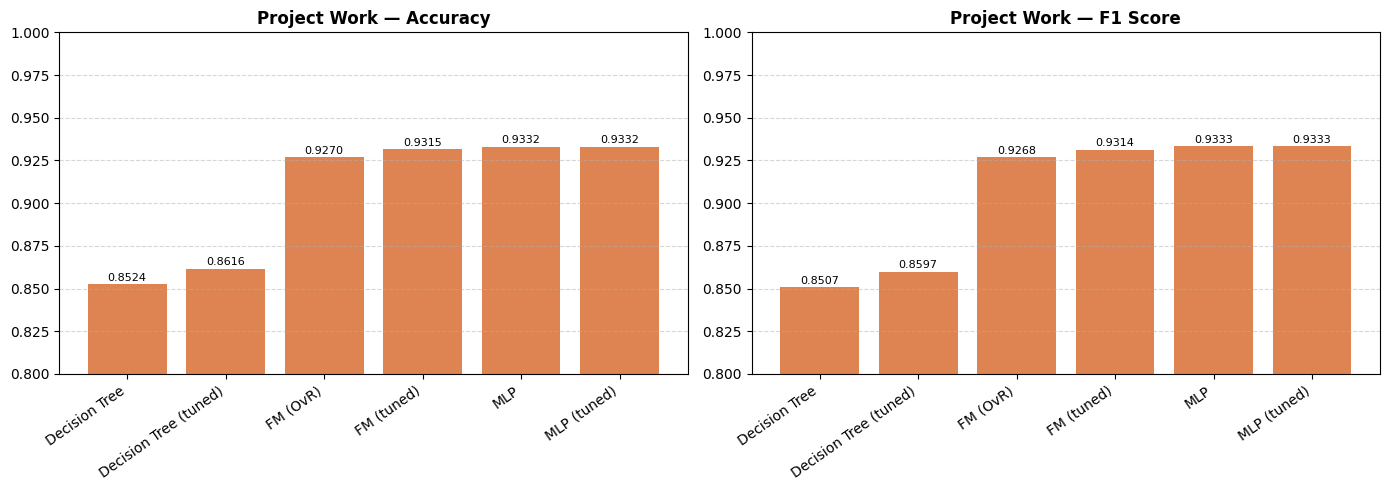

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, metric in zip(axes, ["Accuracy", "F1 Score"]):
    bars = ax.bar(
        project_results["Algorithm"],
        project_results[metric],
        color="#DD8452"
    )
    
    ax.set_title(f"Project Work — {metric}", fontsize=12, fontweight="bold")
    ax.set_xticklabels(project_results["Algorithm"], rotation=35, ha="right")
    ax.set_ylim(0.80, 1.0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    for bar, val in zip(bars, project_results[metric]):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("project_work_metrics.png", dpi=150)
plt.show()